In [1]:
import matplotlib.pyplot as plt 
import numpy as np 
import scipy as sp 
import pandas as pd 

# The Potential Limitations of Correlational Analysis with Ordinal Data


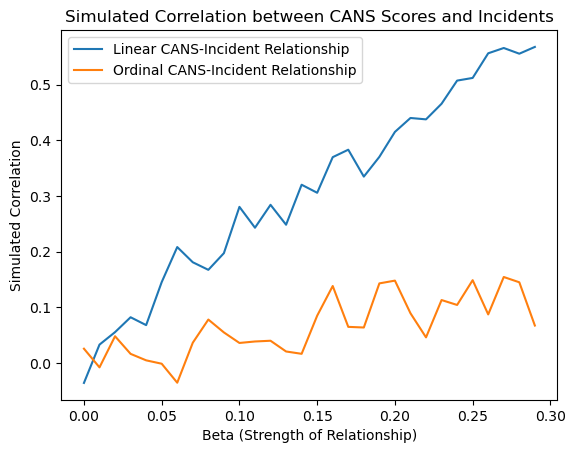

In [2]:
np.random.seed(seed = 42)

def simulate_score_incident_correlation(beta, alpha = 0.1, non_linear = False, f = None, spearman = True): 
    
    non_random_scores = np.sort(
        np.random.choice(
        [0, 1, 2, 3],
        size=1000,
        replace=True,
        p=[0.552915, 0.248545, 0.147856, 0.050684] # Empirical distribution of CANS scores in our dataset
    )
    )

    non_random_incidents = np.zeros(1000, dtype=int)

    for i in [0, 1, 2, 3]:
        score_cnt = np.sum(non_random_scores == i)
        
        p_one = alpha + i * beta
        
        if non_linear == True:
            p_one = alpha + f(i, beta)
        
        p_zero = 1 - p_one

        non_random_incident = np.random.choice(
            [0, 1],
            size=score_cnt,
            p=[p_zero, p_one]
        )

        non_random_incidents[non_random_scores == i] = non_random_incident
    correlation = sp.stats.pearsonr(non_random_scores, non_random_incidents)[0]
    spearman = sp.stats.spearmanr(non_random_scores, non_random_incidents)[0]
    if spearman == True: 
        correlation = spearman 
    return correlation 


def f(i, beta, ps = [0.01, 0.05, 0.25, 0.75]): 
    if i == 0: 
        return ps[0] * beta 
    elif i == 1: 
        return ps[1] * beta 
    elif i == 2: 
        return ps[2] * beta 
    else: 
        return ps[3] * beta

 
    

betas = np.arange(0.00, 0.3, 0.01)
beta_correlation = np.array([])
beta_correlation_non_linear = np.array([]) 
beta_correlation_non_linear_spearman = np.array([])

for beta in betas:  
    beta_correlation = np.append(beta_correlation, simulate_score_incident_correlation(beta))
    beta_correlation_non_linear = np.append(beta_correlation_non_linear, simulate_score_incident_correlation(beta, non_linear=True, f = f))


plt.plot(betas, beta_correlation)
plt.plot(betas, beta_correlation_non_linear)

plt.legend(['Linear CANS-Incident Relationship', 'Ordinal CANS-Incident Relationship'])
plt.xlabel('Beta (Strength of Relationship)')
plt.ylabel('Simulated Correlation')
plt.title('Simulated Correlation between CANS Scores and Incidents');

     

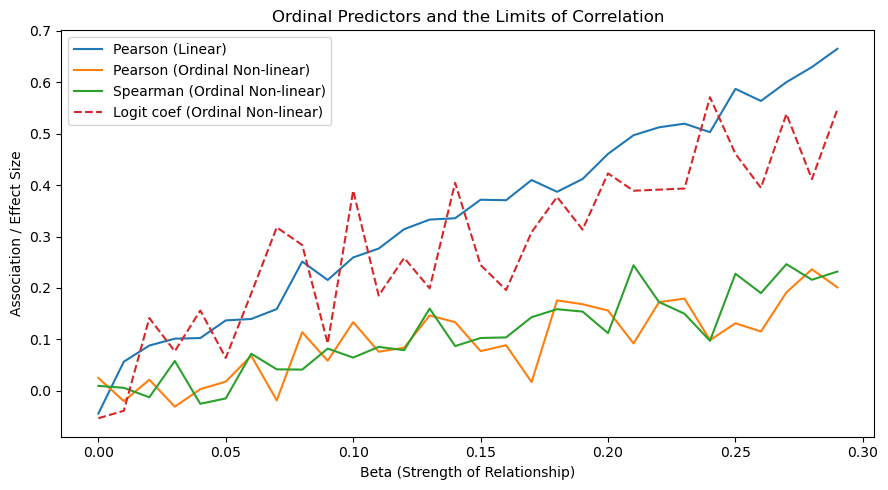

In [3]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import statsmodels.api as sm

np.random.seed(42)


def simulate_score_incident_association(
    beta,
    alpha=0.1,
    non_linear=False,
    f=None,
    method="pearson",
    n=1000,
    ps=[0.25, 0.25, 0.25, 0.25],
    return_data=False
):
    scores = np.random.choice([0, 1, 2, 3], size=n, p=ps)
    incidents = np.zeros(n, dtype=int)

    for i in range(4):
        idx = scores == i

        if non_linear:
            p_one = alpha + f(i, beta)
        else:
            p_one = alpha + i * beta

        p_one = np.clip(p_one, 0, 1)
        incidents[idx] = np.random.binomial(1, p_one, size=idx.sum())

    if return_data:
        return scores, incidents

    if method == "pearson":
        return sp.stats.pearsonr(scores, incidents)[0]
    elif method == "spearman":
        return sp.stats.spearmanr(scores, incidents)[0]
    else:
        raise ValueError("method must be 'pearson' or 'spearman'")


def f(i, beta, ps=[0.01, 0.05, 0.25, 0.75]):
    return ps[i] * beta


def logistic_coef(scores, incidents):
    X = sm.add_constant(scores)
    model = sm.Logit(incidents, X)
    result = model.fit(disp=False)
    return result.params[1]  

betas = np.arange(0.00, 0.3, 0.01)

pearson_linear = np.zeros(len(betas))
pearson_nonlinear = np.zeros(len(betas))
spearman_nonlinear = np.zeros(len(betas))

logit_linear = np.zeros(len(betas))
logit_nonlinear = np.zeros(len(betas))

for j, beta in enumerate(betas):
   
    pearson_linear[j] = simulate_score_incident_association(
        beta, method="pearson"
    )
    pearson_nonlinear[j] = simulate_score_incident_association(
        beta, non_linear=True, f=f, method="pearson"
    )
    spearman_nonlinear[j] = simulate_score_incident_association(
        beta, non_linear=True, f=f, method="spearman"
    )
    scores, incidents = simulate_score_incident_association(
        beta, return_data=True
    )
    logit_linear[j] = logistic_coef(scores, incidents)

    scores, incidents = simulate_score_incident_association(
        beta, non_linear=True, f=f, return_data=True
    )
    logit_nonlinear[j] = logistic_coef(scores, incidents)

plt.figure(figsize=(9, 5))

plt.plot(betas, pearson_linear, label="Pearson (Linear)")
plt.plot(betas, pearson_nonlinear, label="Pearson (Ordinal Non-linear)")
plt.plot(betas, spearman_nonlinear, label="Spearman (Ordinal Non-linear)")
#plt.plot(betas, logit_linear, "--", label="Logit coef (Linear)")
plt.plot(betas, logit_nonlinear, "--", label="Logit coef (Ordinal Non-linear)")

plt.xlabel("Beta (Strength of Relationship)")
plt.ylabel("Association / Effect Size")
plt.title("Ordinal Predictors and the Limits of Correlation")
plt.legend()
plt.tight_layout()
plt.show()


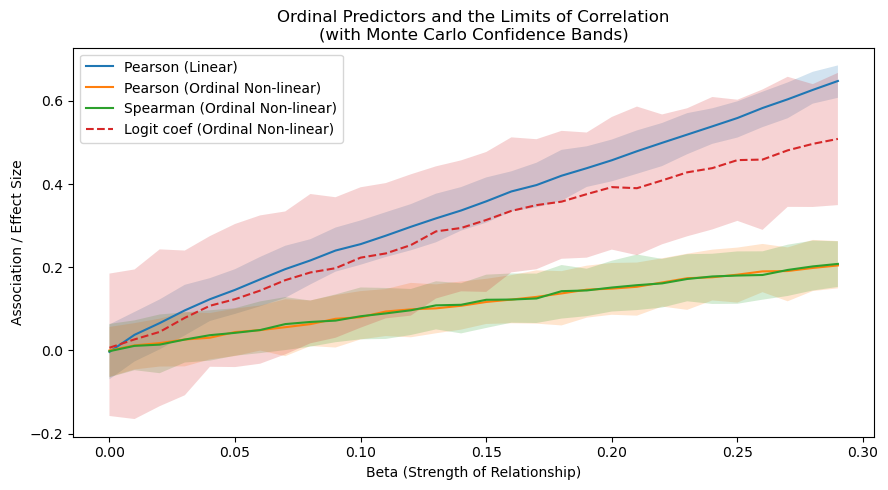

In [4]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import statsmodels.api as sm

np.random.seed(42)


def simulate_score_incident_association(
    beta,
    alpha=0.1,
    non_linear=False,
    f=None,
    method="pearson",
    n=1000,
    ps=[0.25, 0.25, 0.25, 0.25],
    return_data=False
):
    scores = np.random.choice([0, 1, 2, 3], size=n, p=ps)
    incidents = np.zeros(n, dtype=int)

    for i in range(4):
        idx = scores == i

        if non_linear:
            p_one = alpha + f(i, beta)
        else:
            p_one = alpha + i * beta

        p_one = np.clip(p_one, 0, 1)
        incidents[idx] = np.random.binomial(1, p_one, size=idx.sum())

    if return_data:
        return scores, incidents

    if method == "pearson":
        return sp.stats.pearsonr(scores, incidents)[0]
    elif method == "spearman":
        return sp.stats.spearmanr(scores, incidents)[0]
    else:
        raise ValueError("method must be 'pearson' or 'spearman'")


def f(i, beta, ps=[0.01, 0.05, 0.25, 0.75]):
    return ps[i] * beta


def logistic_coef(scores, incidents):
    X = sm.add_constant(scores)
    model = sm.Logit(incidents, X)
    result = model.fit(disp=False)
    return result.params[1]


betas = np.arange(0.00, 0.3, 0.01)
n_sims = 200        # <--- tunable number of simulations
ci = (2.5, 97.5)    # confidence interval percentiles


pearson_linear = np.zeros((len(betas), n_sims))
pearson_nonlinear = np.zeros_like(pearson_linear)
spearman_nonlinear = np.zeros_like(pearson_linear)
logit_nonlinear = np.zeros_like(pearson_linear)


for j, beta in enumerate(betas):
    for s in range(n_sims):

        pearson_linear[j, s] = simulate_score_incident_association(
            beta, method="pearson"
        )

        pearson_nonlinear[j, s] = simulate_score_incident_association(
            beta, non_linear=True, f=f, method="pearson"
        )

        spearman_nonlinear[j, s] = simulate_score_incident_association(
            beta, non_linear=True, f=f, method="spearman"
        )

        scores, incidents = simulate_score_incident_association(
            beta, non_linear=True, f=f, return_data=True
        )
        logit_nonlinear[j, s] = logistic_coef(scores, incidents)



def summarize(x, ci=(2.5, 97.5)):
    mean = x.mean(axis=1)
    lo = np.percentile(x, ci[0], axis=1)
    hi = np.percentile(x, ci[1], axis=1)
    return mean, lo, hi


pl_m, pl_lo, pl_hi = summarize(pearson_linear, ci)
pn_m, pn_lo, pn_hi = summarize(pearson_nonlinear, ci)
sn_m, sn_lo, sn_hi = summarize(spearman_nonlinear, ci)
ln_m, ln_lo, ln_hi = summarize(logit_nonlinear, ci)


plt.figure(figsize=(9, 5))

plt.plot(betas, pl_m, label="Pearson (Linear)")
plt.fill_between(betas, pl_lo, pl_hi, alpha=0.2)

plt.plot(betas, pn_m, label="Pearson (Ordinal Non-linear)")
plt.fill_between(betas, pn_lo, pn_hi, alpha=0.2)

plt.plot(betas, sn_m, label="Spearman (Ordinal Non-linear)")
plt.fill_between(betas, sn_lo, sn_hi, alpha=0.2)

plt.plot(betas, ln_m, "--", label="Logit coef (Ordinal Non-linear)")
plt.fill_between(betas, ln_lo, ln_hi, alpha=0.2)

plt.xlabel("Beta (Strength of Relationship)")
plt.ylabel("Association / Effect Size")
plt.title("Ordinal Predictors and the Limits of Correlation\n(with Monte Carlo Confidence Bands)")
plt.legend()
plt.tight_layout()
plt.show()


# Simulating Correlations Between Scores

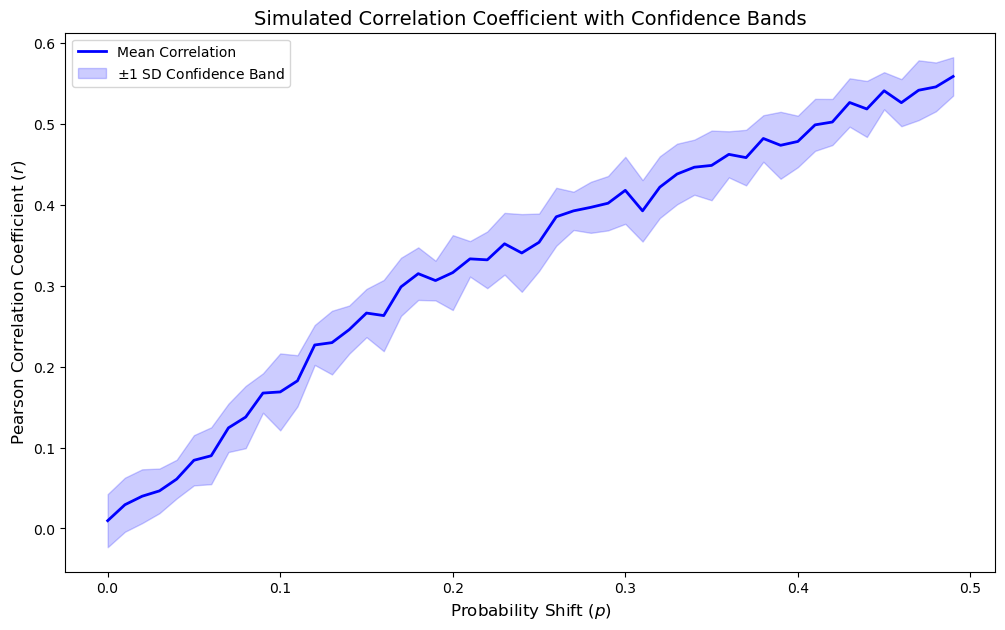

In [5]:


def simulate_corr_between_cans(p):
    base_p = np.array([0.552915, 0.248545, 0.147856, 0.050684])
    scores = np.array([0, 1, 2, 3])
    
    can_scores = np.random.choice(scores, size=1000, replace=True, p=base_p)
    correlated_scores = []
    
    for score in can_scores:
        new_p = base_p.copy()
        new_p[score] += p
        for offset in [-2, 2]:
            target_idx = score + offset
            if 0 <= target_idx <= 3:
                new_p[target_idx] -= p
        new_p = np.clip(new_p, 0, 1)
        new_p /= new_p.sum()
        correlated_scores.append(np.random.choice(scores, p=new_p))

    return np.corrcoef(can_scores, np.array(correlated_scores))[0, 1]

def corr_as_func_of_p(max_prob): 
    probs = np.arange(0, max_prob, 0.01)
    
    means = []
    stds = []
    
    for p in probs:
        trials = [simulate_corr_between_cans(p) for _ in range(20)]
        means.append(np.mean(trials))
        stds.append(np.std(trials))
        
    means = np.array(means)
    stds = np.array(stds)
    
    plt.figure(figsize=(12, 7))
    

    plt.plot(probs, means, color='blue', label='Mean Correlation', linewidth=2)
    
   
    plt.fill_between(
        probs, 
        means - stds, 
        means + stds, 
        color='blue', 
        alpha=0.2, 
        label='$\pm$1 SD Confidence Band'
    )
    
    plt.title('Simulated Correlation Coefficient with Confidence Bands', fontsize=14)
    plt.xlabel('Probability Shift ($p$)', fontsize=12)
    plt.ylabel('Pearson Correlation Coefficient ($r$)', fontsize=12)
    plt.legend()
    plt.savefig('correlation_vs_p_with_bands.png')
    plt.show()

corr_as_func_of_p(0.5)
    
    


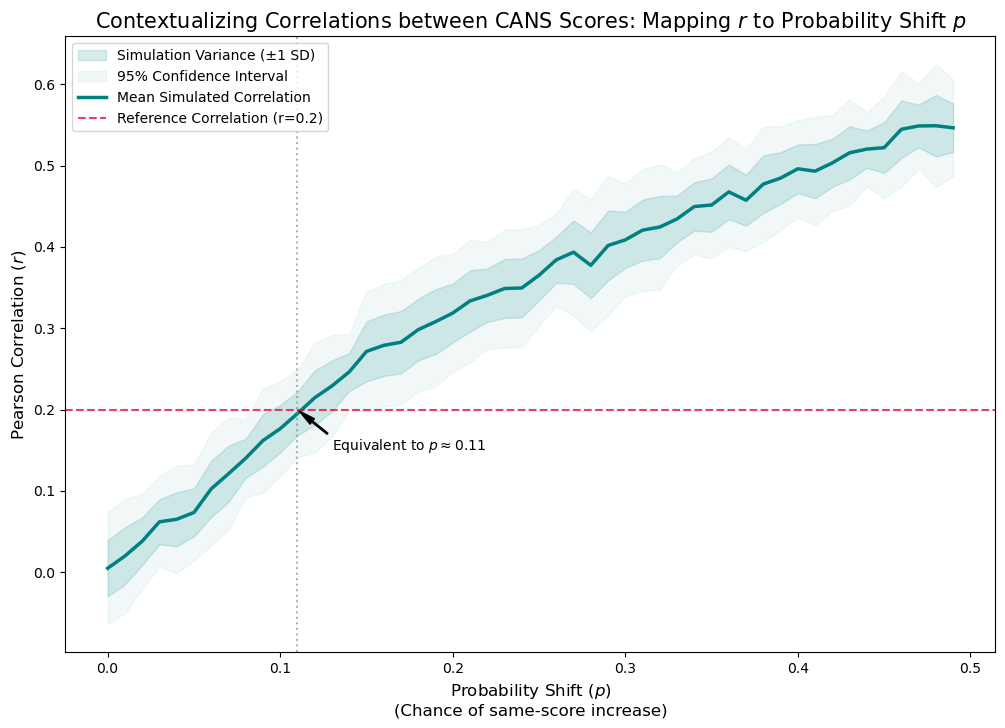

In [6]:


def simulate_corr_between_cans(p, size=1000):
    base_p = np.array([0.552915, 0.248545, 0.147856, 0.050684])
    scores = np.array([0, 1, 2, 3])
    
    can_scores = np.random.choice(scores, size=size, replace=True, p=base_p)
    correlated_scores = []
    
    for score in can_scores:
        new_p = base_p.copy()
        new_p[score] += p
       
        for offset in [-2, 2]:
            target_idx = score + offset
            if 0 <= target_idx <= 3:
                new_p[target_idx] -= p
        
        new_p = np.clip(new_p, 0, 1)
        new_p /= new_p.sum()
        correlated_scores.append(np.random.choice(scores, p=new_p))

    return np.corrcoef(can_scores, np.array(correlated_scores))[0, 1]

def plot_contextual_simulation(max_p, target_r=0.43): 
    probs = np.arange(0, max_p, 0.01)
    means, stds = [], []
    
    for p in probs:
        trials = [simulate_corr_between_cans(p) for _ in range(30)] 
        means.append(np.mean(trials))
        stds.append(np.std(trials))
        
    means, stds = np.array(means), np.array(stds)
    
    plt.figure(figsize=(12, 8))
    
    plt.fill_between(probs, means - stds, means + stds, color='teal', alpha=0.15, label='Simulation Variance (±1 SD)')
    plt.fill_between(probs, means - (2*stds), means + (2*stds), color='teal', alpha=0.05, label='95% Confidence Interval')
    
   
    plt.plot(probs, means, color='teal', linewidth=2.5, label='Mean Simulated Correlation')
    
    
    plt.axhline(y=target_r, color='crimson', linestyle='--', alpha=0.8, label=f'Reference Correlation (r={target_r})')
    
   
    idx = np.argmin(np.abs(means - target_r))
    plt.axvline(x=probs[idx], color='gray', linestyle=':', alpha=0.6)
    plt.annotate(f'Equivalent to $p \\approx {probs[idx]:.2f}$', 
                 xy=(probs[idx], target_r), xytext=(probs[idx]+0.02, target_r-0.05),
                 arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=5))

    plt.title(f'Contextualizing Correlations between CANS Scores: Mapping $r$ to Probability Shift $p$', fontsize=15)
    plt.xlabel('Probability Shift ($p$)\n(Chance of same-score increase)', fontsize=12)
    plt.ylabel('Pearson Correlation ($r$)', fontsize=12)
    plt.legend(loc='upper left')
    plt.show()

plot_contextual_simulation(0.5, target_r=0.2)

# Observations 
1. Even when there is an extremely strong and notable relationship between the CANS score the probability of an incident (in the non-linear case a score of 3 increases the chance of an incident by 22.5 percent) the correlation between non-linearity of the ordinal metric leads to a $\rho < 0.1$

2. As the true effect of the ordinal score on incident probability increases, the logistic regression coefficient increases monotonically, reflecting the underlying data-generating process. In contrast, Pearson and Spearman correlations saturate and substantially attenuate the apparent association, particularly under non-linear ordinal effects.








